<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-03-18 23:50:40--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.3’

survey-data.csv.3   100%[===================>] 152.13M  46.2MB/s    in 3.3s    

2026-03-18 23:50:45 (46.4 MB/s) - ‘survey-data.csv.3’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


Yearly comp 25th percentile is 60000.0, and 75th percentile is 250000.0
Yearly comp 25th Interquartile Range is 190000.0
Any compensation above $535000.0 or below $-225000.0 is a statistical outlier


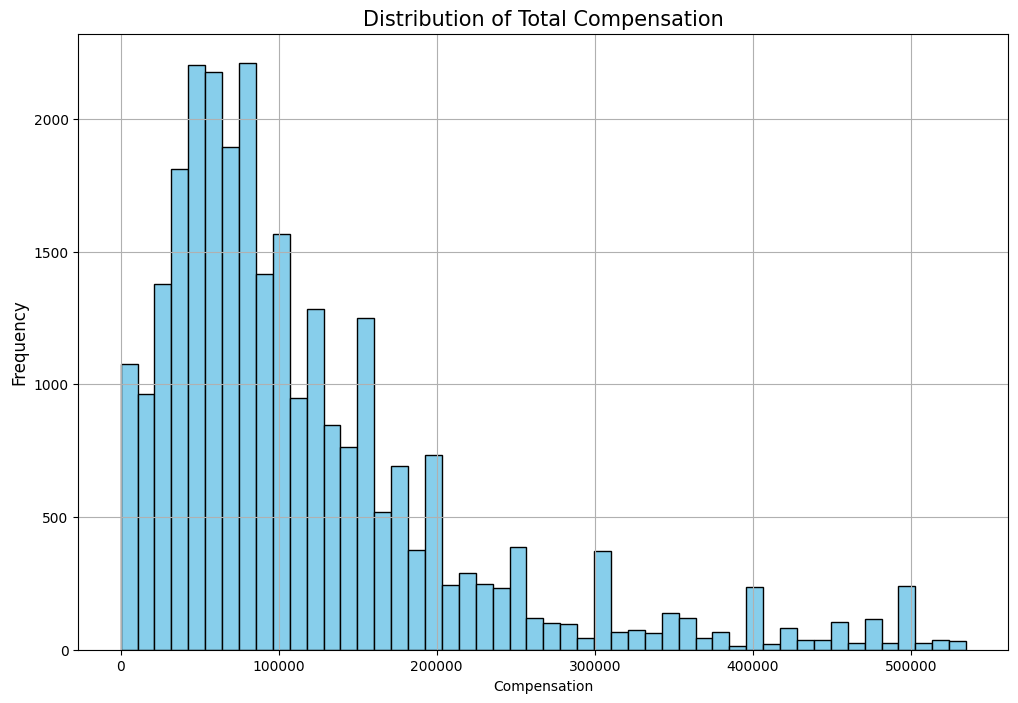

In [10]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT CompTotal FROM main
    WHERE CompTotal IS NOT NULL
    AND CompTotal !='';
"""
df_comptotal = pd.read_sql_query(QUERY, conn)

#calculate first (25%) and third (75%) quartiles for ConvertedCompYearly
Q1 = df_comptotal['CompTotal'].quantile(0.25)
Q3 = df_comptotal['CompTotal'].quantile(0.75)
print(f'Yearly comp 25th percentile is {Q1}, and 75th percentile is {Q3}')

#calculate Interquartile Range (IQR) for ConvertedCompYearly
IQR = Q3-Q1
print(f'Yearly comp 25th Interquartile Range is {IQR}')

#Determine upper and lower bounds for outliers
#Tukey's Fences outlier is any value 1.5 times the IQR above Q3 or below Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Any compensation above ${upper_bound} or below ${lower_bound} is a statistical outlier')

#make a new dataframe by filtering, keeping only rows that fall within upper and lower bounds
df_no_outliers = df_comptotal[(df_comptotal['CompTotal'] >= lower_bound) & 
                    (df_comptotal['CompTotal'] <= upper_bound)]


#Plot a histogram 
plt.figure(figsize= (12,8))

ax = df_no_outliers['CompTotal'].hist(bins=50, edgecolor='black', color='skyblue')

#Define labels and title
plt.title('Distribution of Total Compensation', fontsize=15)
plt.xlabel('Compensation')
plt.ylabel('Frequency', fontsize=12)

plt.show()



**Box Plots**

Plot a box plot of Age.


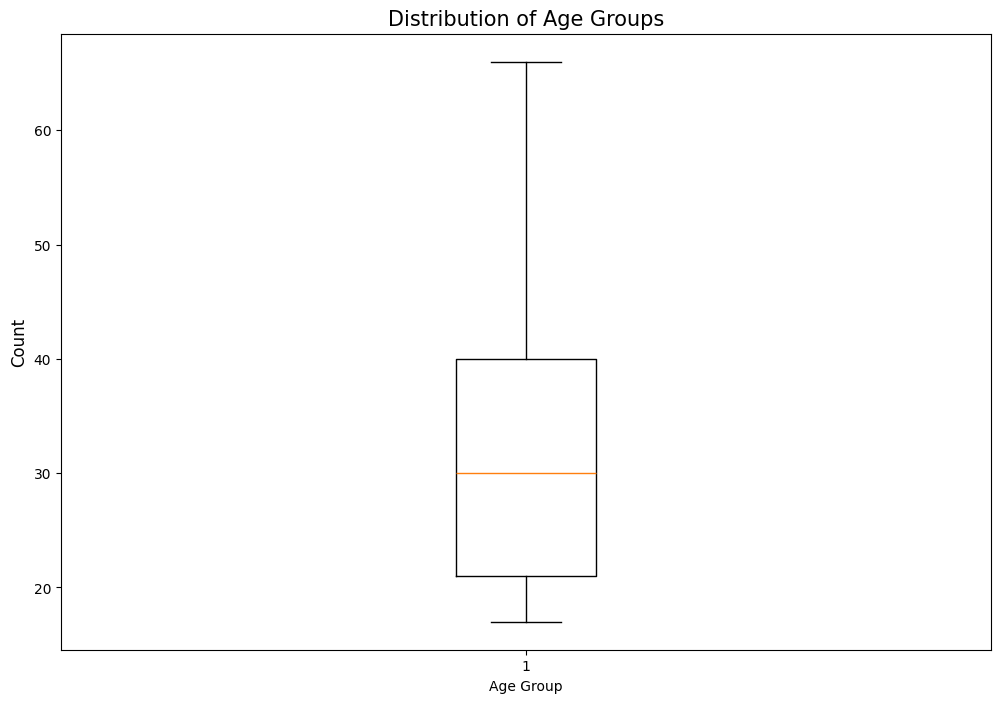

,Age,ResponseId,Age_Numeric
0,18-24 years old,4,21.0
1,18-24 years old,5,21.0
2,18-24 years old,8,21.0
3,18-24 years old,18,21.0
4,18-24 years old,37,21.0
...,...,...,...
65432,Under 18 years old,65234,17.0
65433,Under 18 years old,65278,17.0
65434,Under 18 years old,65387,17.0
65435,Under 18 years old,65421,17.0


In [11]:
## Write your code here
import numpy as np

#Select the data of interest from SQL
QUERY = """
SELECT Age, ResponseID
FROM main
WHERE Age IS NOT NULL
AND Age !=''
ORDER BY Age;
"""
df_age = pd.read_sql_query(QUERY, conn)

#Define the numeric ages based on 'Age' answers
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}

# Apply the mapping to create a new numeric column
df_age['Age_Numeric'] = df_age['Age'].map(age_mapping)

#Plot a box plot of Age categories
plt.figure(figsize= (12,8))

plt.boxplot(df_age['Age_Numeric'].dropna())


#Define labels and title
plt.title('Distribution of Age Groups', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Count', fontsize=12)

plt.show()

df_age




### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


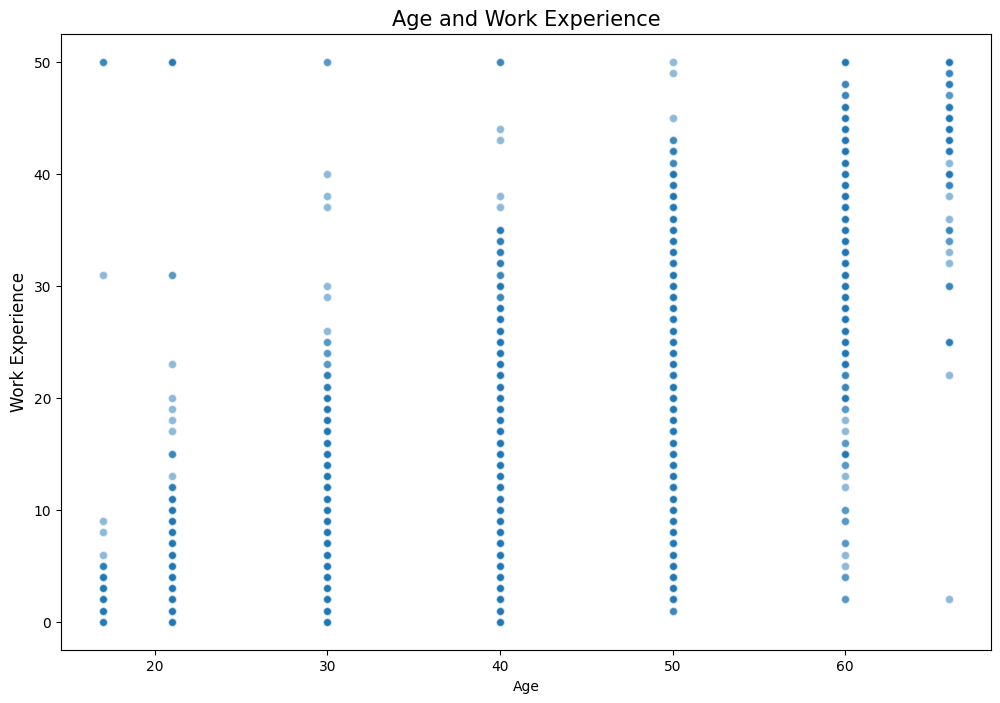

In [12]:
## Write your code here
import numpy as np

#Select the data of interest from SQL
QUERY = """
SELECT Age, WorkExp
FROM main
WHERE Age IS NOT NULL
AND Age !=''
ORDER BY Age;
"""
df_work = pd.read_sql_query(QUERY, conn)

#Define the numeric ages based on 'Age' answers
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}

# Apply the mapping to create a new numeric column
df_work['Age_Numeric'] = df_work['Age'].map(age_mapping)

#clean data so nan's are removed so x and y are same size
df_work_clean = df_work.dropna(subset=['Age_Numeric', 'WorkExp'])

#Plot a scatter plot of Age categories
plt.figure(figsize= (12,8))

plt.scatter(df_work_clean['Age_Numeric'], df_work_clean['WorkExp'], alpha = 0.5, edgecolors='w')


#Define labels and title
plt.title('Age and Work Experience', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Work Experience', fontsize=12)

plt.show()



**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


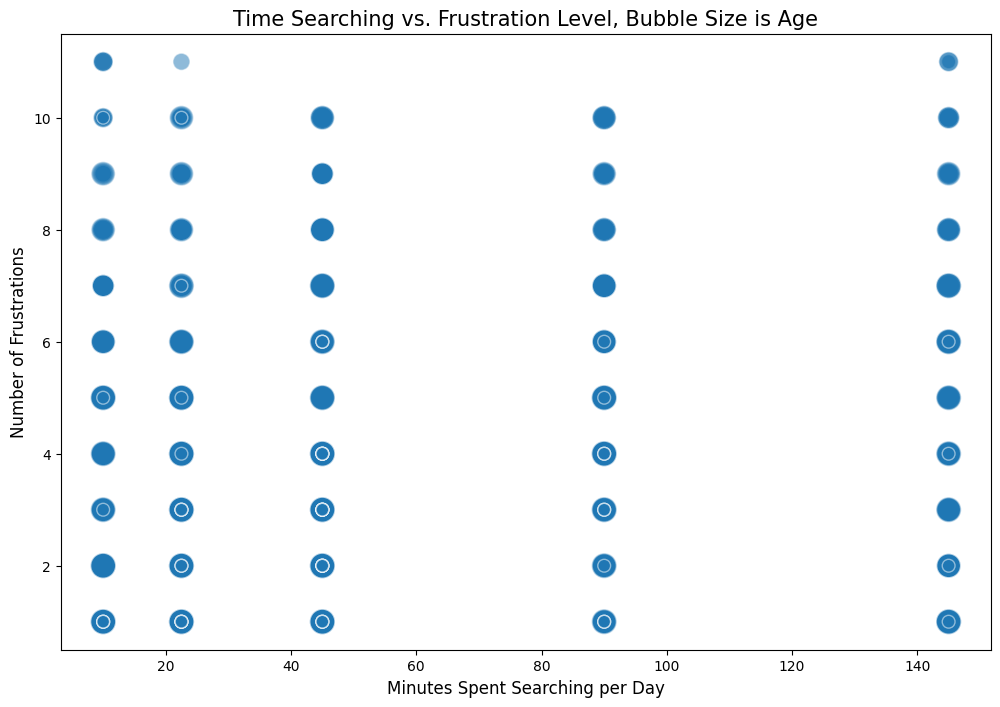

In [40]:
## Write your code here

import numpy as np

#Select the data of interest from SQL
QUERY = """
SELECT Age, TimeSearching, Frustration
FROM main
WHERE Age IS NOT NULL
AND Age !=''
ORDER BY Age;
"""
df_bubble = pd.read_sql_query(QUERY, conn)

#Define the numeric ages based on 'Age' answers
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 66,
    'Prefer not to say': np.nan
}

# Apply the mapping to create a new numeric column
df_bubble['Age_Numeric'] = df_bubble['Age'].map(age_mapping)

#Define the numeric time searching based on 'TimeSearching' answers
time_mapping = {
    '30-60 minutes a day': 45,
    '15-30 minutes a day': 22.5,
    '60-120 minutes a day': 90,
    'Less than 15 minutes a day': 10,
    'Over 120 minutes a day': 145,
}

# Apply the mapping to create a new numeric column
df_bubble['Minutes_Searching'] = df_bubble['TimeSearching'].map(time_mapping)

#clean data so nan's are removed so x and y are same size
df_bubble_clean = df_bubble.dropna(subset=['Age_Numeric', 'Minutes_Searching', 'Frustration'])

#Code showing the unique values of Frustration shows many strings separated by a ; 
#and TimeSearching are categorical
#Need to transform data into numerical values 
df_bubble_clean['Frustration'].unique()
df_bubble_clean['TimeSearching'].unique()

#Split semicolon separated strings into list for Frustration
#need to create a numerical 'Frustration count' based on number of items selected
df_bubble_clean['Frustration_counts'] = df_bubble_clean['Frustration'].str.split(';').str.len()

#Plot a bubble plot of Time searching and frustration metrics with Age as bubble size
plt.figure(figsize= (12,8))

plt.scatter(
    df_bubble_clean['Minutes_Searching'], 
    df_bubble_clean['Frustration_counts'], 
    s=df_bubble_clean['Age_Numeric'] * 5, #make the bubble sizes larger 
    alpha = 0.5, 
    edgecolors='w')

#Define labels and title
plt.title('Time Searching vs. Frustration Level, Bubble Size is Age', fontsize=15)
plt.xlabel('Minutes Spent Searching per Day', fontsize=12)
plt.ylabel('Number of Frustrations', fontsize=12)

plt.show()


### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


Total unique database categories: 36
The top 5 databases responders would like to learn are ['PostgreSQL', 'SQLite', 'MySQL', 'MongoDB', 'Redis']


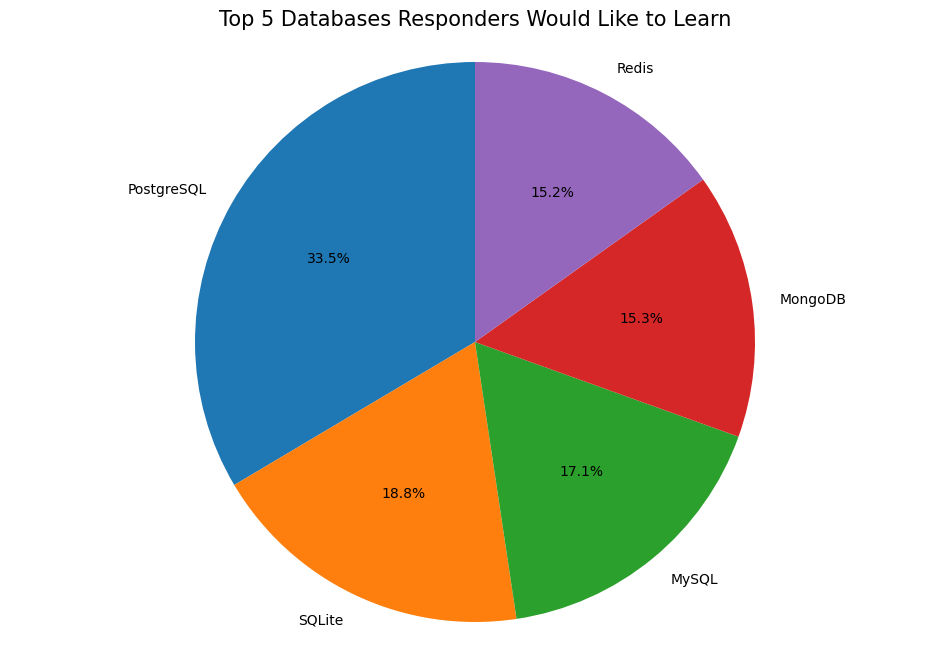

In [33]:
## Write your code here
## Write your code here
import numpy as np

#Select the data of interest from SQL
QUERY = """
SELECT DatabaseWantToWorkWith, ResponseID
FROM main
"""
df_databases = pd.read_sql_query(QUERY, conn)

#Look at unique responses to see how to handle responses
df_databases['DatabaseWantToWorkWith'].unique()

#Split the semicolon-separated strings into lists
df_databases['Database_List'] = df_databases['DatabaseWantToWorkWith'].str.split(';')

#Explode the lists so each DatabaseWantToWorkWith gets its own row
df_databases = df_databases.explode('Database_List')

#Get counts of individaul databases
database_counts = df_databases['Database_List'].value_counts()

#Get top 5 databases
top_5_databases = database_counts.head(5)

print(f"Total unique database categories: {len(unique_databases)}")
print(f'The top 5 databases responders would like to learn are {top_5_databases.index.to_list()}')

#Create pie chart of top 5 databases responders want to learn 
plt.figure(figsize = (12, 8))
plt.pie(
    top_5_databases,
    labels = top_5_databases.index,
    autopct='%1.1f%%', #shows one decimal place
    startangle=90)

#Define labels and title
plt.title('Top 5 Databases Responders Would Like to Learn', fontsize=15)
plt.axis('equal') #ensures pie is a circle, not an oval

plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


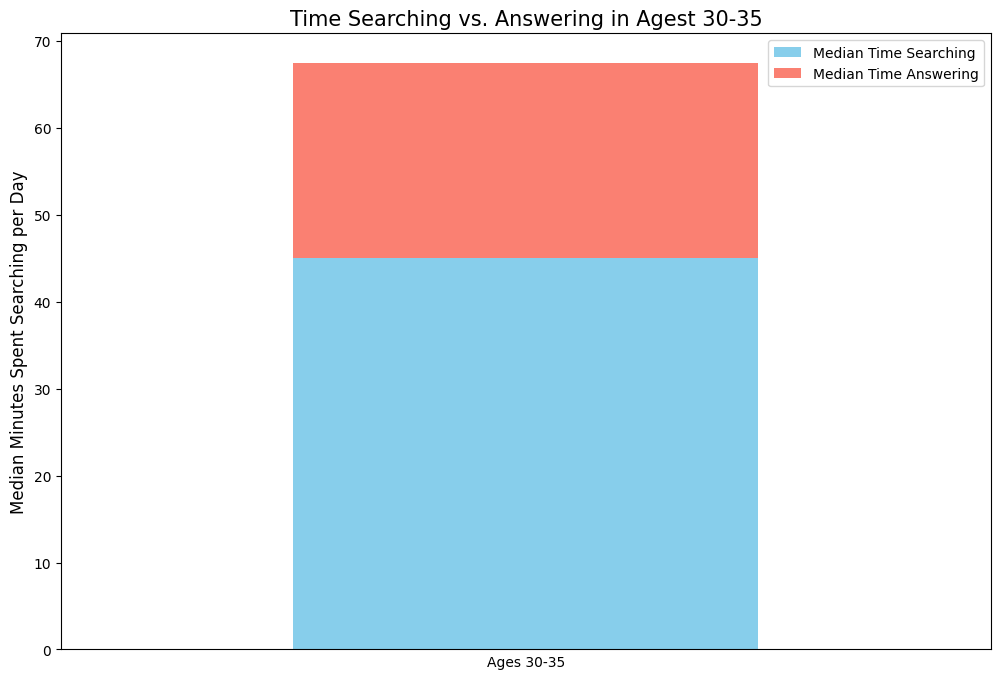

In [44]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE (Age = '25-34 years old' OR Age= '35-44 years old')
AND Age !=''
ORDER BY Age;
"""
df_stacked = pd.read_sql_query(QUERY, conn)

#Define the numeric time searching based on 'TimeSearching' answers
time_mapping = {
    '30-60 minutes a day': 45,
    '15-30 minutes a day': 22.5,
    '60-120 minutes a day': 90,
    'Less than 15 minutes a day': 10,
    'Over 120 minutes a day': 145,
}

# Apply the mapping to create a new numeric column
df_stacked['Minutes_Searching'] = df_stacked['TimeSearching'].map(time_mapping)
df_stacked['Minutes_Answering'] = df_stacked['TimeAnswering'].map(time_mapping)

#clean data so nan's are removed so x and y are same size
df_stacked_clean = df_stacked.dropna(subset=['Age', 'Minutes_Searching', 'Minutes_Answering'])

#Find the medians
# This gives you the "middle" value for Searching and the "middle" value for Answering
medians = df_stacked_clean[['Minutes_Searching', 'Minutes_Answering']].median()

#Plot a bubble plot of Time searching and frustration metrics with Age as bubble size
plt.figure(figsize= (12,8))

# .to_frame().T flips the two medians so they sit on top of each other
ax= medians.to_frame().T.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], ax=plt.gca())

#Define labels and title
plt.title('Time Searching vs. Answering in Agest 30-35', fontsize=15)
plt.ylabel('Median Minutes Spent Searching per Day', fontsize=12)
plt.xlabel('Ages 30-35')
plt.xticks([], []) # Hide the bottom index label
plt.legend(['Median Time Searching', 'Median Time Answering'], loc='upper right')

plt.show()



### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


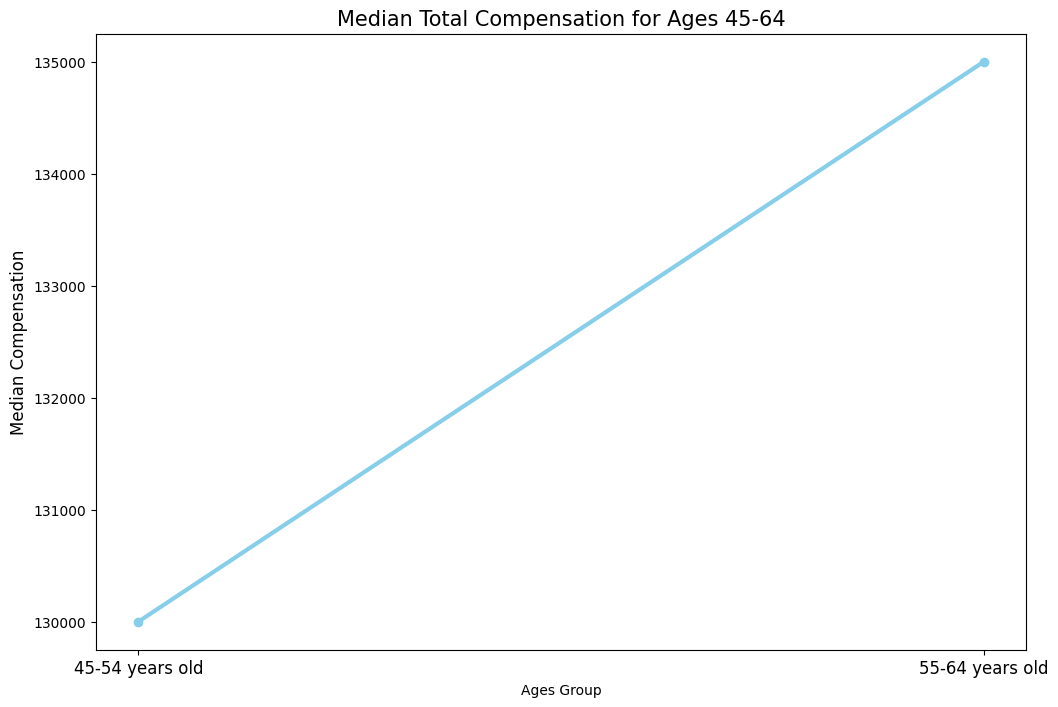

In [56]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE (Age = '45-54 years old' OR Age= '55-64 years old')
AND Age !=''
ORDER BY Age;
"""
df_line = pd.read_sql_query(QUERY, conn)

#clean data so nan's are removed so x and y are same size
df_line_clean = df_line.dropna(subset=['Age', 'CompTotal'])

#Find the medians and group by Age
# This gives you the "middle" value for Searching and the "middle" value for Answering
comp_median = df_line_clean.groupby('Age')['CompTotal'].median()

#Plot a bubble plot of Time searching and frustration metrics with Age as bubble size
plt.figure(figsize= (12,8))

# .to_frame().T flips the two medians so they sit on top of each other
ax= comp_median.plot(kind='line', marker='o', color='skyblue', linewidth=3)

# Force both labels to appear
plt.xticks(ticks=np.arange(len(comp_median)), labels=comp_median.index, fontsize=12)


#Define labels and title
plt.title('Median Total Compensation for Ages 45-64', fontsize=15)
plt.ylabel('Median Compensation', fontsize=12)
plt.xlabel('Ages Group')

plt.show()


**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


<Figure size 2000x1200 with 0 Axes>

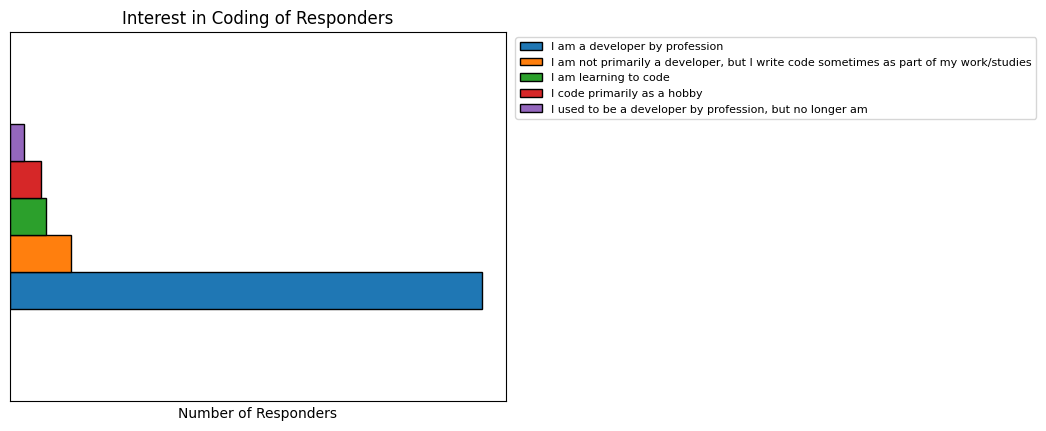

In [88]:
## Write your code here

#Select the data of interest from SQL
QUERY = """
SELECT MainBranch
FROM main
"""
df_bar = pd.read_sql_query(QUERY, conn)


main_values = df_bar['MainBranch'].value_counts()
main_values

#Plot a bubble plot of Time searching and frustration metrics with Age as bubble size
plt.figure(figsize= (20,12))

# .to_frame().T flips the two medians so they sit on top of each other
ax= main_values.to_frame().T.plot(kind='barh', edgecolor='black')

#Define labels and title
plt.title('Interest in Coding of Responders', fontsize=12)
plt.xlabel('Number of Responders')
plt.xticks([], []) # Hide the bottom index label
plt.legend(loc='upper right', bbox_to_anchor = (2.08,1), fontsize=8)
plt.yticks([], []) # Hide the label


plt.show()


### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
